In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import ast
import seaborn as sns
from datasets import load_dataset

datas = load_dataset('lukebarousse/data_jobs')

df = datas['train'].to_pandas()
# df = pd.read_csv('../data_jobs.csv')

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)
countries = ['Denmark','Netherlands','Sweden','Norway','Belgium','Luxemburg','Ireland']
european_countries = [
    # Western Europe
    'Austria', 'Belgium', 'France', 'Germany', 'Liechtenstein', 
    'Luxembourg', 'Monaco', 'Netherlands', 'Switzerland',
    
    # Northern Europe & Nordics / Baltics
    'Denmark', 'Estonia', 'Finland', 'Iceland', 'Ireland', 
    'Latvia', 'Lithuania', 'Norway', 'Sweden', 'United Kingdom',
    
    # Southern Europe
    'Albania', 'Andorra', 'Bosnia and Herzegovina', 'Croatia', 'Cyprus', 
    'Gibraltar', 'Greece', 'Italy', 'Malta', 'Montenegro', 
    'North Macedonia', 'Portugal', 'San Marino', 'Serbia', 'Slovenia', 'Spain',
    
    # Eastern Europe
    'Belarus', 'Bulgaria', 'Czechia', 
    'Czech Republic', 'Georgia', 'Hungary', 
    'Poland', 'Romania', 'Slovakia'
]
jobs = sorted(['Data Engineer', 'Data Scientist'])
dfe = df[df["job_title_short"].isin(jobs)].copy()
dfe = dfe[dfe['job_country'].isin(countries)] #change this accordingly with countries of interest

In [ ]:
dfe['job_posted_month_no'] = dfe['job_posted_date'].dt.month
dfex = dfe.explode("job_skills")
dfep = dfex.pivot_table(
    index="job_posted_month_no",
    columns="job_skills",
    aggfunc="size",
    fill_value=0,
)
top_skills_order = dfep.sum(axis=0).sort_values(ascending=False).index
dfep = dfep[top_skills_order]

dftotals = dfe.groupby('job_posted_month_no').size()
dfepp = dfep.div(dftotals/100,axis=0)

dfepp.index = pd.to_datetime(dfepp.index, format="%m").strftime("%b")
dfepp.index.name = "job_posted_month"
dfepp = dfepp.iloc[:, :5]

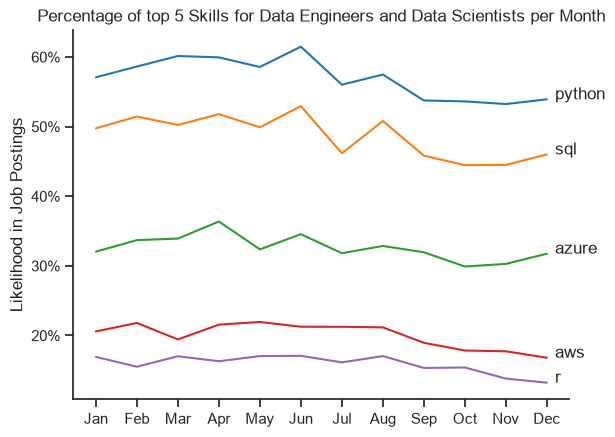

In [3]:
sns.set_theme(style='ticks')
sns.lineplot(data=dfepp,dashes=False,palette='tab10')
sns.despine()


plt.title('Percentage of top 5 Skills for Data Engineers and Data Scientists per Month')
plt.ylabel('Likelihood in Job Postings')
plt.xlabel('')
plt.legend().set_visible(False)
for i in range(5):
    plt.text(11.2,dfepp.iloc[-1,i],dfepp.columns[i])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'{int(x)}%'))
plt.show()